In [4]:
# =========================================================
# ЕТАП 1: Ініціалізація, Імпорт та Завантаження Даних
# =========================================================

# 1. Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import os # Додано для діагностики файлів
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt 


# 2. КОНСТАНТИ
FILE_NAME = 'CarPrice_Assignment.csv' 
Y_TARGET = 'price' # Цільова змінна
# Ознаки для МНОЖИННОЇ РЕГРЕСІЇ
X_FEATURES_MULTI = ['enginesize', 'horsepower', 'curbweight'] 
RANDOM_SEED = 42
print(f"Обрані ознаки (X): {X_FEATURES_MULTI}")
print(f"Цільова змінна (Y): {Y_TARGET}")

# 3. Завантаження даних
try:
    df_car = pd.read_csv(FILE_NAME)
    print(f"\n✅ Дані успішно завантажено. Об'єктів: {df_car.shape[0]}, Колонок: {df_car.shape[1]}")

except FileNotFoundError:
    # БЛОК ДІАГНОСТИКИ (спрацює, якщо файл не знайдено)
    print(f"\n❌ Помилка: Файл '{FILE_NAME}' не знайдено.")
    print("-------------------------------------------------------")
    print("Файли, наявні в поточній робочій директорії:")
    try:
        current_files = os.listdir('.')
        print(current_files)
    except Exception as e:
        print(f"Не вдалося отримати список файлів: {e}")
    print("-------------------------------------------------------")
    print("Перевірте, чи назва файлу CarPrice_Assignment.csv збігається з назвою у списку.")
    exit() # Зупиняємо виконання, якщо файл не знайдено


# 4. Огляд перших рядків
print("\nПерші 5 рядків набору даних:")
print(df_car.head())


# =========================================================
# ЕТАП 2: Попередня Обробка та Підготовка Даних
# (Для Множинної Регресії)
# =========================================================

# 1. Очищення даних від пропусків 
# Видаляємо, якщо пропуски є у будь-якій з обраних ознак X або Y
columns_to_check = X_FEATURES_MULTI + [Y_TARGET]
df_clean = df_car.dropna(subset=columns_to_check)
print(f"\nКількість об'єктів після очищення: {df_clean.shape[0]}")


# 2. Вибір ознак (X) та цільової змінної (y)
# X тепер містить ТРИ колонки!
X = df_clean[X_FEATURES_MULTI] 
y = df_clean[Y_TARGET]


# 3. Розбиття на навчальний (train) та тестовий (test) набори
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"\n--- Підготовка даних завершена ---")
print(f"Розмір навчального набору (train): {X_train.shape[0]} об'єктів.")
print(f"Розмір тестового набору (test): {X_test.shape[0]} об'єктів.")

Обрані ознаки (X): ['enginesize', 'horsepower', 'curbweight']
Цільова змінна (Y): price

✅ Дані успішно завантажено. Об'єктів: 205, Колонок: 26

Перші 5 рядків набору даних:
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8

In [5]:
# 1. Очищення даних від пропусків (простий метод)
# Хоча цей набір зазвичай чистий, це обов'язковий крок
df_clean = df_car.dropna(subset=[X_FEATURE, Y_TARGET])

# 2. Вибір ознак (X) та цільової змінної (y)
# X (enginesize) повинен бути двовимірним, тому використовуємо [[...]]
X = df_clean[[X_FEATURE]] 
y = df_clean[Y_TARGET]

# 3. Розбиття на навчальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("\n--- Підготовка даних ---")
print(f"Цільова змінна (Y): {Y_TARGET}")
print(f"Ознака (X): {X_FEATURE}")
print(f"Розмір навчального набору (train): {X_train.shape[0]} об'єктів.")
print(f"Розмір тестового набору (test): {X_test.shape[0]} об'єктів.")


--- Підготовка даних ---
Цільова змінна (Y): price
Ознака (X): enginesize
Розмір навчального набору (train): 164 об'єктів.
Розмір тестового набору (test): 41 об'єктів.


In [6]:
# 1. Ініціалізація та навчання моделі
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Прогноз на тестовому наборі
y_pred = model.predict(X_test)

# 3. Оцінка моделі
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- Результати Лінійної Регресії (Моделювання) ---")
print(f"Коефіцієнт R-squared (R2): {r2:.4f}")
print(f"Корінь із MSE (RMSE): {rmse:.2f} (У валюті ціни)")

# 4. Рівняння прямої (інтерпретація)
b0 = model.intercept_
b1 = model.coef_[0]
print(f"\nПараметри моделі:")
print(f"b0 (Intercept): {b0:.2f}")
print(f"b1 (Coefficient для {X_FEATURE}): {b1:.2f}")
print(f"Рівняння: Price = {b0:.2f} + {b1:.2f} * {X_FEATURE}")


--- Результати Лінійної Регресії (Моделювання) ---
Коефіцієнт R-squared (R2): 0.8041
Корінь із MSE (RMSE): 3932.61 (У валюті ціни)

Параметри моделі:
b0 (Intercept): -7741.77
b1 (Coefficient для enginesize): 165.84
Рівняння: Price = -7741.77 + 165.84 * enginesize


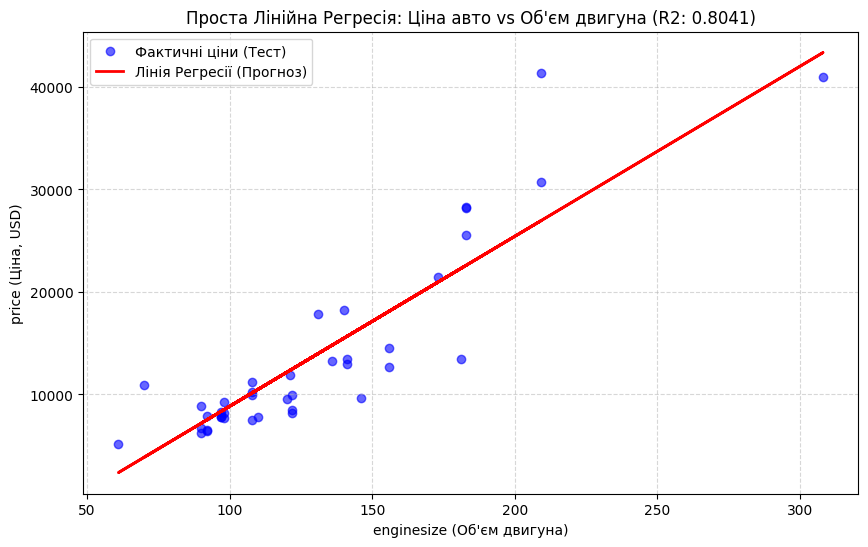

In [7]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))

# Точки: Фактичні дані (тестовий набір)
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Фактичні ціни (Тест)')

# Лінія: Прогноз моделі
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Лінія Регресії (Прогноз)')

# Оформлення
plt.title(f'Проста Лінійна Регресія: Ціна авто vs Об\'єм двигуна (R2: {r2:.4f})')
plt.xlabel(f'{X_FEATURE} (Об\'єм двигуна)')
plt.ylabel(f'{Y_TARGET} (Ціна, USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()